# Imports

In [1]:
!pip install pytorch-lightning
!pip install torchmetrics
!pip install torchshow
!pip install albumentations


[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import zipfile
from pathlib import Path
from typing import Callable, Tuple

import gdown

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchshow as ts
import torch.optim as optim
import torchmetrics
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import VGG16_Weights
from pytorch_lightning.callbacks import ModelCheckpoint
import pytorch_lightning as pl

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
from tqdm.notebook import tqdm
from IPython.display import Image, display
from PIL import Image

import albumentations as A

# Variable declaration

In [3]:
url__data_origin = "https://drive.google.com/drive/folders/10KMK0rNB43V2g30NcA1RYipL535DuZ-h"
fil__raw_dataset_trainvalidation = "train_val.zip"
fil__raw_dataset_test = "TEST.zip"

dir__running = os.path.join(os.getcwd(), "..")
dir__raw_data = os.path.join(dir__running, "data", "raw")

path__raw_dataset_trainvalidation = os.path.join(dir__raw_data, fil__raw_dataset_trainvalidation)
path__raw_dataset_test = os.path.join(dir__raw_data, fil__raw_dataset_test)

dir__dataset = os.path.join(dir__running, "data", "dataset")
dir__dataset_trainvalidation = os.path.join(dir__dataset, "train-validation")
dir__dataset_test = os.path.join(dir__dataset, "test")

dir__dataset_trainvalidation_images = os.path.join(dir__dataset_trainvalidation, "images")
dir__dataset_trainvalidation_labels = os.path.join(dir__dataset_trainvalidation, "masks")

dir__dataset_test_images = os.path.join(dir__dataset_test, "images")
dir__dataset_test_labels = os.path.join(dir__dataset_test, "masks")


val_to_color = {
    0: "#000000",
    1: "#0000FF",
    2: "#00FFFF",
    3: "#FF0000",
    4: "#FF00FF",
    5: "#FFFF00",
}
cmap = ListedColormap([val_to_color[key] for key in sorted(val_to_color.keys())])
norm = BoundaryNorm(range(len(val_to_color) + 1), cmap.N)

# Data acquisition

In [4]:
def ensure_dir(dir):
    if not os.path.exists(dir):
        os.makedirs(dir)


def download_from_google_drive(url, file_path):
    print(f"Downloading {url} to {file_path}...")
    gdown.download_folder(url__data_origin, quiet = False, output = file_path)
    print("Download completed.")


def unzip_file(zip_path, target_dir):
    ensure_dir(target_dir)
    if not os.path.exists(target_dir) or len(os.listdir(target_dir)) == 0:
        print(f"extracting {zip_path} to {target_dir}...")
        file_name = os.path.basename(zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(target_dir)
        for file in os.listdir(os.path.join(target_dir, file_name.split(".")[0])):
            os.rename(
                os.path.join(target_dir, file_name.split(".")[0], file),
                os.path.join(target_dir, file),
            )
        os.rmdir(os.path.join(target_dir, file_name.split(".")[0]))
        print(f"{zip_path} successfully extracted to {target_dir}.")
    else:
        print(f"{zip_path} already extracted to {target_dir}.")

In [5]:
ensure_dir(dir__raw_data)

if not os.path.isfile(path__raw_dataset_trainvalidation) or not os.path.isfile(path__raw_dataset_test):
    download_from_google_drive(url__data_origin, dir__raw_data)
else:
    print("Raw datasets already downloaded.")

if not os.path.isfile(path__raw_dataset_trainvalidation) or not os.path.isfile(path__raw_dataset_test):
    raise FileNotFoundError("Raw datasets not found.")

unzip_file(path__raw_dataset_trainvalidation, dir__dataset_trainvalidation)
unzip_file(path__raw_dataset_test, dir__dataset_test)

Raw datasets already downloaded.
c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\raw\train_val.zip already extracted to c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\dataset\train-validation.
c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\raw\TEST.zip already extracted to c:\Users\Seya.Schmassmann\Code\studium\bverI\bverI-miniproject\src\..\data\dataset\test.


In [6]:
trainvalidation_tuples_paths = [
    (
        os.path.join(dir__dataset_trainvalidation_images, file_name),
        os.path.join(dir__dataset_trainvalidation_labels, file_name.split(".")[0] + ".bmp"),
    )
    for file_name in os.listdir(dir__dataset_trainvalidation_images)
]
test_tuples_paths = [
    (
        os.path.join(dir__dataset_test_images, file_name),
        os.path.join(dir__dataset_test_labels, file_name.split(".")[0] + ".bmp"),
    )
    for file_name in os.listdir(dir__dataset_test_images)
]

# Data analysis

## Categories

| Color                                 | Description               |
| ------------------------------------- | ------------------------- |
| <span style="color:#000000;">⬤</span> | Background waterbody      |
| <span style="color:#0000FF;">⬤</span> | Human divers              |
| <span style="color:#00FF00;">⬤</span> | Plants/sea-grass          |
| <span style="color:#00FFFF;">⬤</span> | Wrecks/ruins              |
| <span style="color:#FF0000;">⬤</span> | Robots/instruments        |
| <span style="color:#FF00FF;">⬤</span> | Reefs and invertebrates   |
| <span style="color:#FFFF00;">⬤</span> | Fish and vertebrates      |
| <span style="color:#FFFFFF;">⬤</span> | Sand/sea-floor (& rocks)  |


In [7]:
colors_to_8cats = {
    (0, 0, 0): 0,        # #000000 --> [BW] Background waterbody
    (0, 0, 255): 1,      # #0000FF --> [HD] Human divers
    (0, 255, 0): 2,      # #00FF00 --> [PF] Plants/sea-grass
    (0, 255, 255): 3,    # #00FFFF --> [WR] Wrecks/ruins
    (255, 0, 0): 4,      # #FF0000 --> [RO] Robots/instruments
    (255, 0, 255): 5,    # #FF00FF --> [RI] Reefs and invertebrates
    (255, 255, 0): 6,    # #FFFF00 --> [FV] Fish and vertebrates
    (255, 255, 255): 7,  # #FFFFFF --> [SR] Sand/sea-floor (& rocks)
}
colors_to_5cats = {
    (0, 0, 0): 0,        # #000000 --> [BW] Background waterbody
    (0, 255, 0): 0,      # #00FF00 --> [PF] Plants/sea-grass
    (255, 255, 255): 0,  # #FFFFFF --> [SR] Sand/sea-floor (& rocks)
    (0, 0, 255): 1,      # #0000FF --> [HD] Human divers
    (0, 255, 255): 2,    # #00FFFF --> [WR] Wrecks/ruins
    (255, 0, 0): 3,      # #FF0000 --> [RO] Robots/instruments
    (255, 0, 255): 4,    # #FF00FF --> [RI] Reefs and invertebrates
    (255, 255, 0): 5,    # #FFFF00 --> [FV] Fish and vertebrates
}

Train-validation dataset contains 1525 images and labels.
Test dataset contains 110 images and labels.

Image dimensions:
  - (480, 640, 3): 1329
  - (720, 1280, 3): 57
  - (448, 480, 3): 16
  - (720, 1152, 3): 8
  - (1080, 1906, 3): 17
  - (360, 640, 3): 17
  - (480, 584, 3): 5
  - (540, 960, 3): 130
  - (600, 800, 3): 13
  - (960, 1280, 3): 1
  - (416, 416, 3): 5
  - (375, 590, 3): 31
  - (435, 910, 3): 6


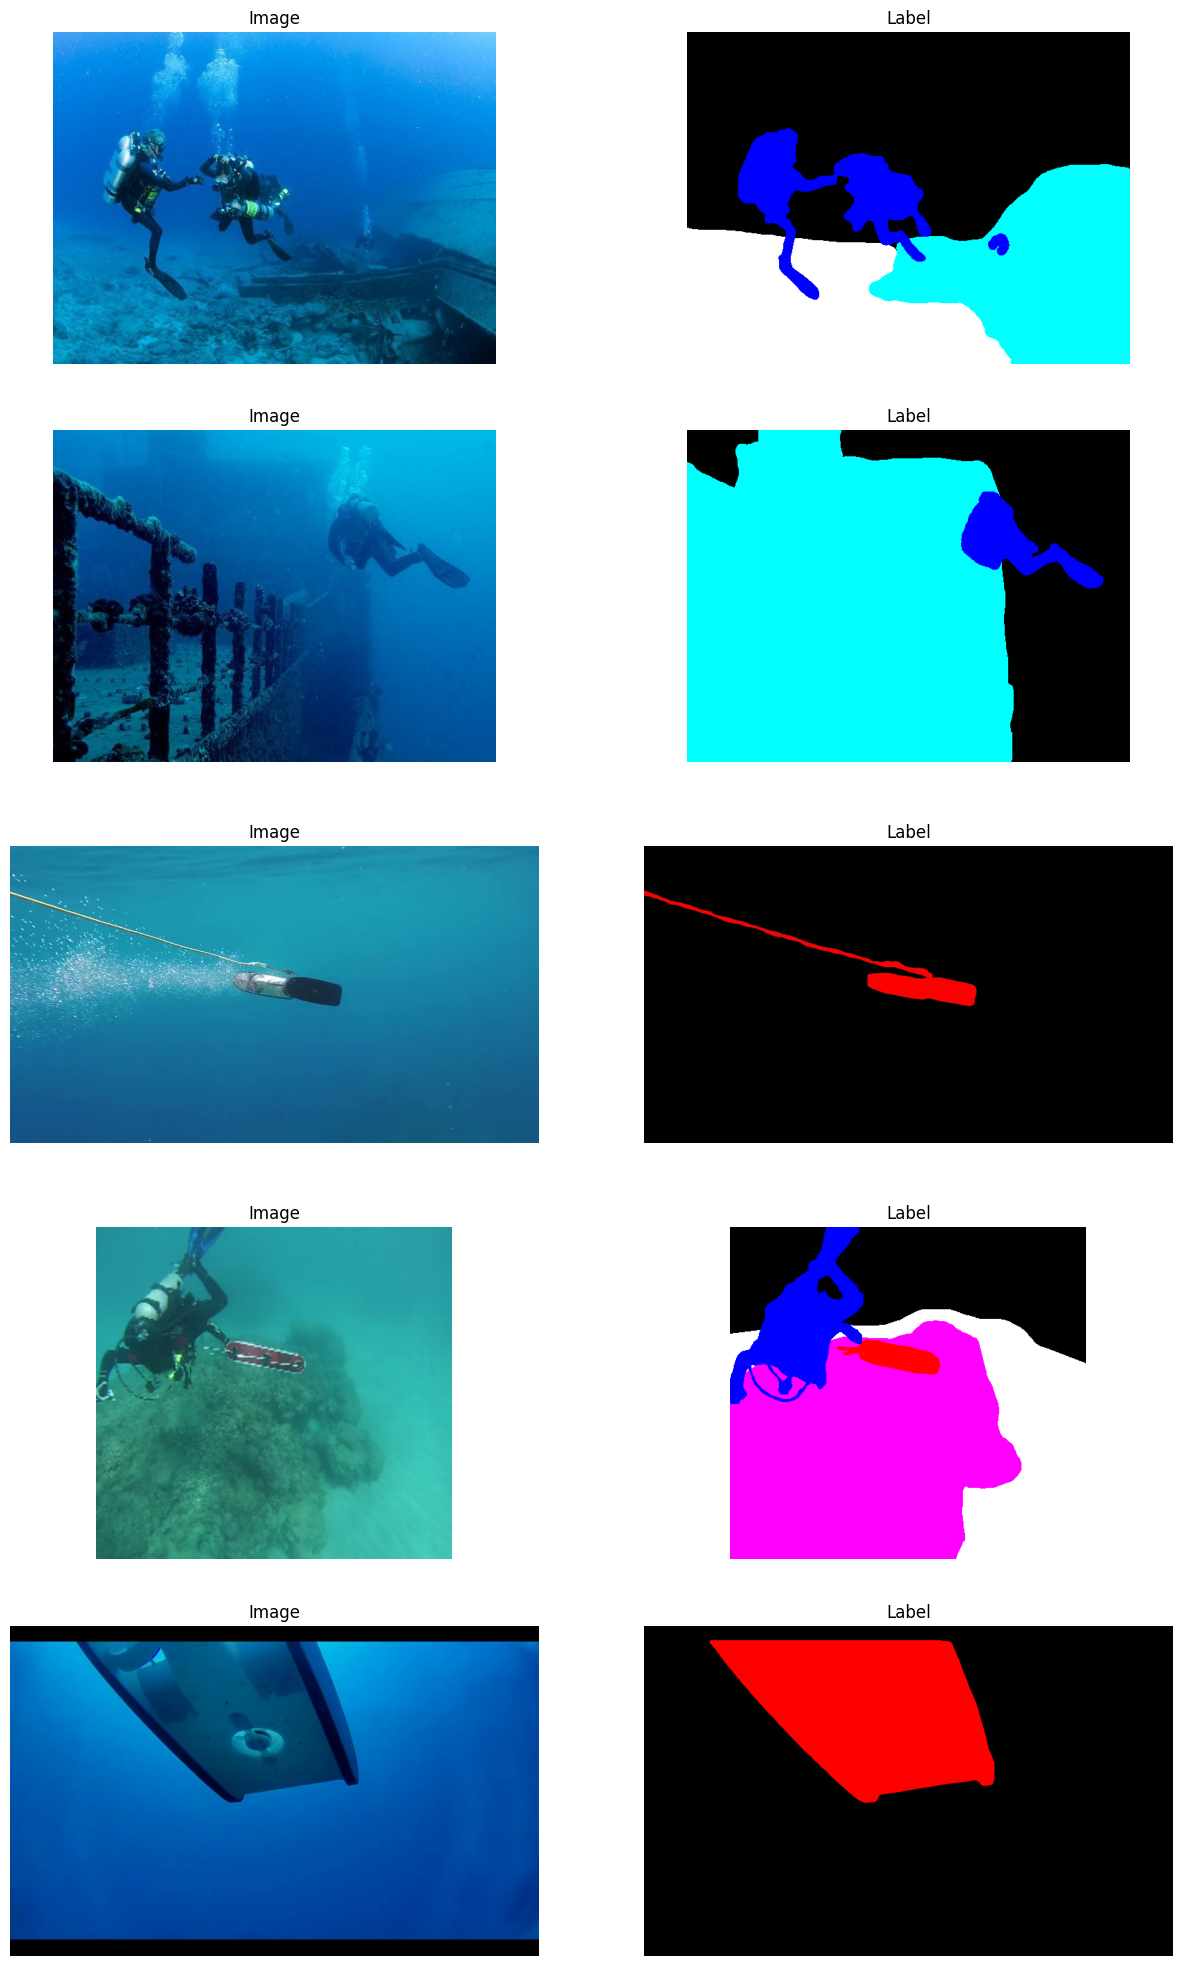

In [8]:
print(f"Train-validation dataset contains {len(trainvalidation_tuples_paths)} images and labels.")
print(f"Test dataset contains {len(test_tuples_paths)} images and labels.")

image_dims = {}
for image_path, label_path in trainvalidation_tuples_paths + test_tuples_paths:
    image = plt.imread(image_path)

    count = image_dims[image.shape] if image.shape in image_dims else 0
    image_dims[image.shape] = count + 1

print("\nImage dimensions:")
for dim, count in image_dims.items():
    print(f"  - {dim}: {count}")

fig, ax = plt.subplots(5, 2, figsize = (15, 25))

for i in range(5):
    _ = ax[i][0].axis("off")
    _ = ax[i][1].axis("off")

    _ = ax[i][0].imshow(plt.imread(trainvalidation_tuples_paths[i][0]))
    _ = ax[i][0].set_title("Image")

    _ = ax[i][1].imshow(plt.imread(trainvalidation_tuples_paths[i][1]))
    _ = ax[i][1].set_title("Label")

plt.show()

# Data preparation

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


## Dataset

In [46]:
class SuimDataset(Dataset):
    def __init__(
        self,
        data_tuples_paths,
        color_mapping: dict,
        transform_images: Callable,
        transform_labels: Callable,
        augmentations: Callable = None,
        verbose: bool = False,
    ):
        """
        Initializes the dataset.

        Args:
            data_tuples_paths (Path): Path to the dataset directory.
            color_mapping (dict): Mapping of RGB colors to class indices.
            transform_images (callable): Transformation function for images.
            transform_labels (callable): Transformation function for labels.
            tolerance (int): Tolerance for color matching.
            augmentations (callable): Augmentation function for images and labels.
            verbose (bool): Whether to display images and labels.
        """
        self.data_tuples_paths = data_tuples_paths
        self.color_mapping = color_mapping
        self.num_classes = max(color_mapping.values()) + 1
        self.transform_images = transform_images
        self.transform_labels = transform_labels
        self.tolerance = 10
        self.augmentations = augmentations
        self.verbose = verbose

    def __len__(self) -> int:
        """
        Returns the length of the dataset.
        """
        return len(self.data_tuples_paths)

    def match_color(self, label_array, target_color):
        """
        Matches the target color in the label array with a given tolerance.

        Args:
            label_array (np.ndarray): The label array (H, W, 3).
            target_color (tuple): The target RGB color.

        Returns:
            np.ndarray: A boolean mask where the color matches approximately.
        """
        return np.all(np.abs(label_array - target_color) <= self.tolerance, axis=-1)

    def __getitem__(self, idx):
        """
        Retrieves the image and corresponding label masks for a given index.

        Args:
            idx (int): The index of the item to retrieve.

        Returns:
            tuple: A tuple containing:
                - image (torch.Tensor | Image.Image): The transformed image or original image.
                - label_masks (torch.Tensor): A binary mask tensor of shape (K, H, W) where K is the number of classes.
                  Each channel represents the binary mask for a specific class.
                - labels_tensor (torch.Tensor): A segmentation map tensor of shape (1, H, W) indicating class indices
                  for each pixel.
        """
        image_path, label_path = self.data_tuples_paths[idx]

        image = Image.open(image_path).convert("RGB")
        label = Image.open(label_path).convert("RGB")

        if self.augmentations:
            augmented = self.augmentations(image = np.array(image), mask = np.array(label))
            image = Image.fromarray(augmented["image"])
            label = Image.fromarray(augmented["mask"])

        image_tensor = self.transform_images(image)
        label = self.transform_labels(label)

        label_categorical = np.zeros((label.height, label.width), dtype = np.uint8)
        label_array = np.array(label)
        for color, cat in self.color_mapping.items():
            color_array = np.array(color)
            mask = self.match_color(label_array, color_array)
            label_categorical[mask] = cat

        if self.verbose:
            print(f"Image shape: {image_tensor.shape}, type: {type(image_tensor)}, dtype: {image_tensor.dtype}")
            print(f"Label shape: {label.size}, type: {type(label)}")

            fig, ax = plt.subplots(2, 2, figsize = (15, 10))

            image_name = os.path.basename(image_path)

            _ = ax[0][0].imshow(image)
            _ = ax[0][0].axis("off")
            _ = ax[0][0].set_title(f"Image {image_name}")
 
            _ = ax[0][1].imshow(label)
            _ = ax[0][1].axis("off")
            _ = ax[0][1].set_title("Label")

            _ = ax[1][0].imshow(label_categorical, cmap = cmap, norm = norm)
            _ = ax[1][0].axis("off")
            _ = ax[1][0].set_title("Label (categorical)")

            _ = ax[1][1].remove()

            plt.show()

        # transform from (H, W) to (1, H, W)
        label_categorical = np.expand_dims(label_categorical, axis = 0)
        labels_tensor = torch.from_numpy(label_categorical).long()
        
        # transform from (1, H, W) to (K, H, W)
        label_masks = F.one_hot(labels_tensor.squeeze(0), num_classes = self.num_classes).permute(2, 0, 1)

        if self.verbose:
            print(f"Label masks shape: {label_masks.shape}, type: {type(label_masks)}, dtype: {label_masks.dtype}, min: {label_masks.min()}, max: {label_masks.max()}")
            print(f"Labels tensor shape: {labels_tensor.shape}, type: {type(labels_tensor)}, dtype: {labels_tensor.dtype}, min: {labels_tensor.min()}, max: {labels_tensor.max()}")


        return image_tensor, label_masks, labels_tensor

### Tests

Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


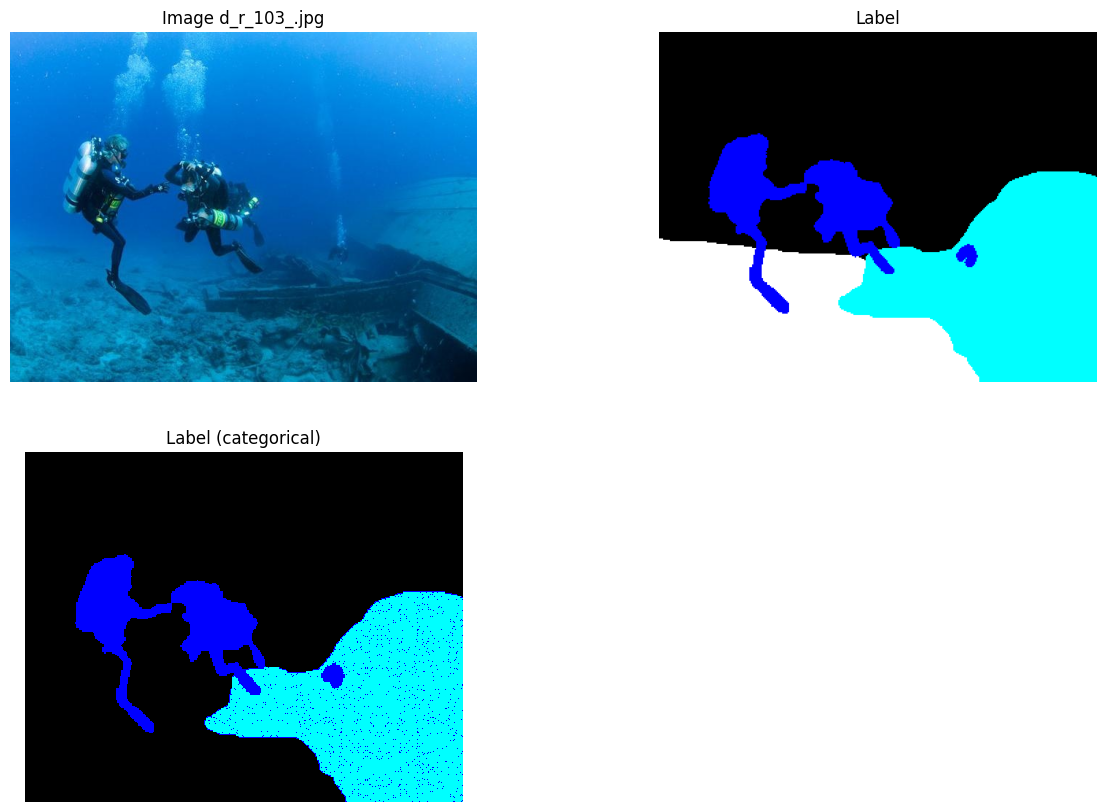

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 2
Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


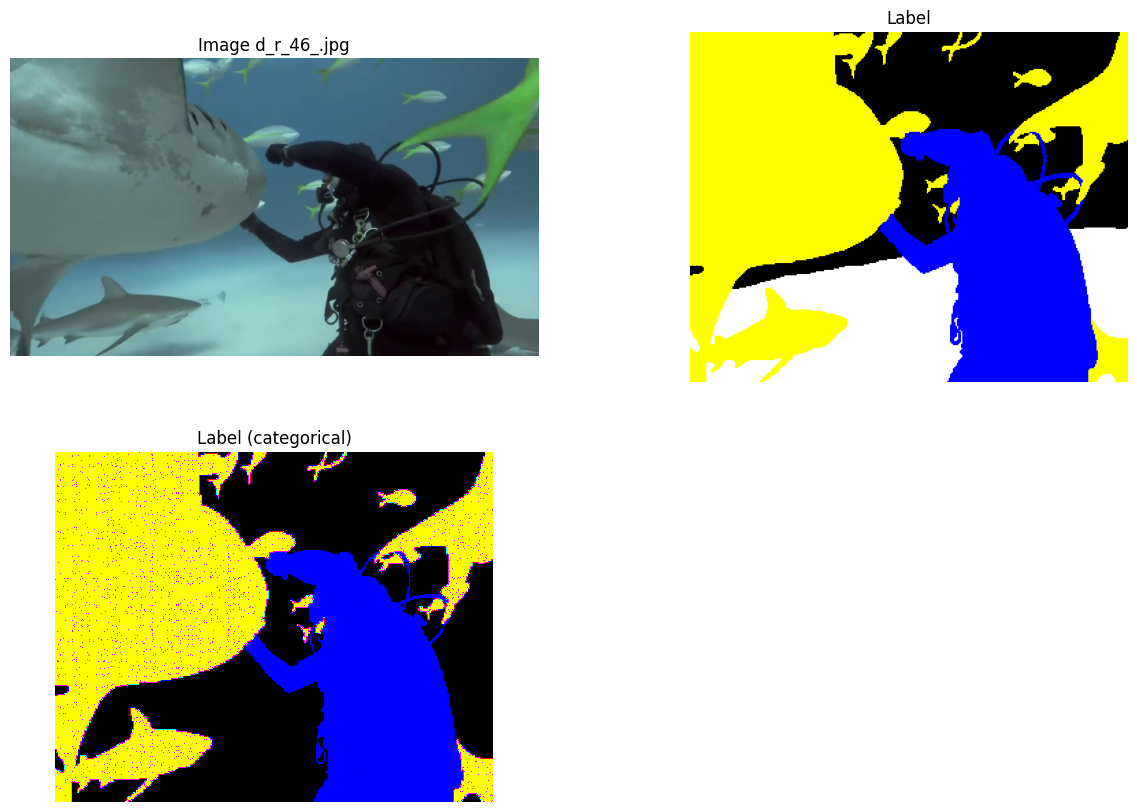

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 5
Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


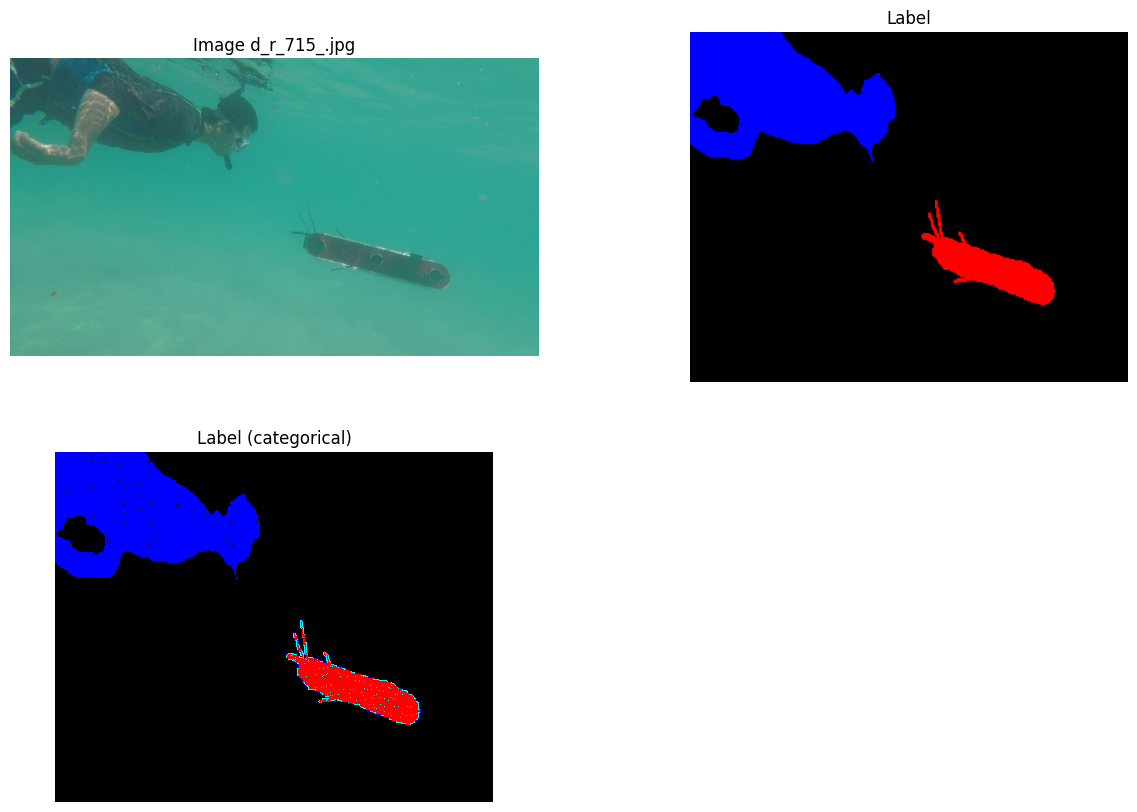

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 3
Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


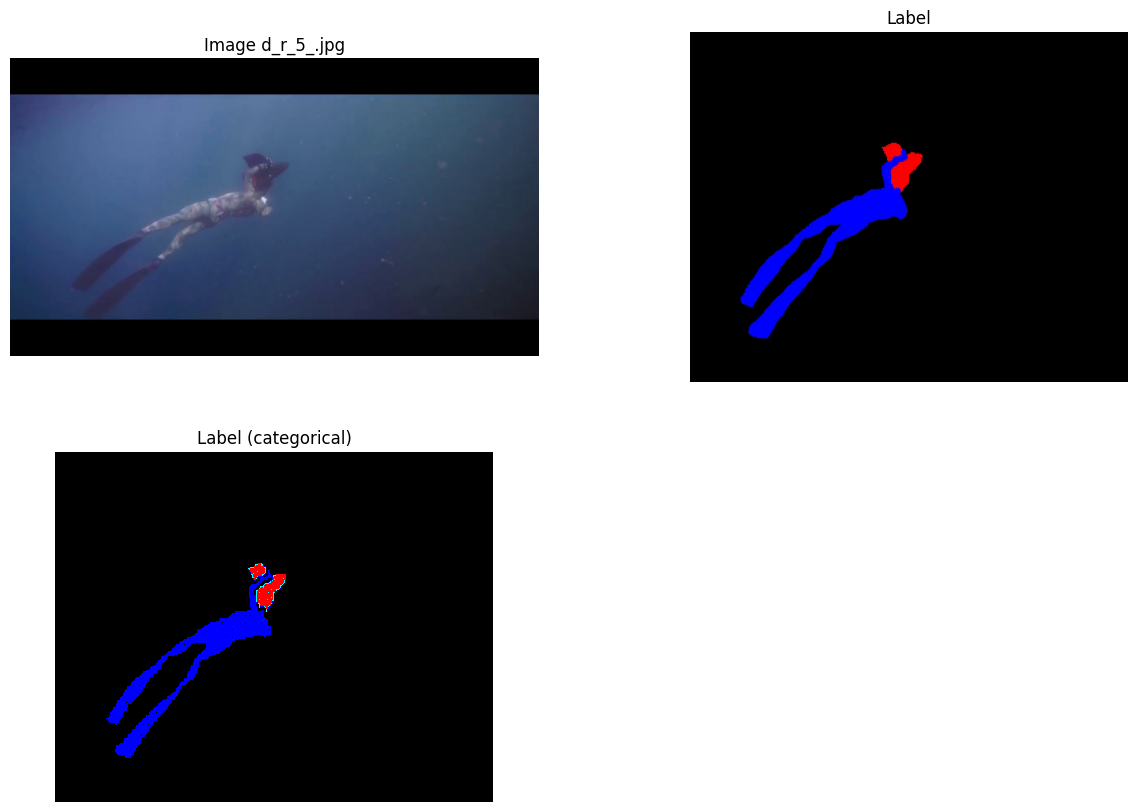

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 3
Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


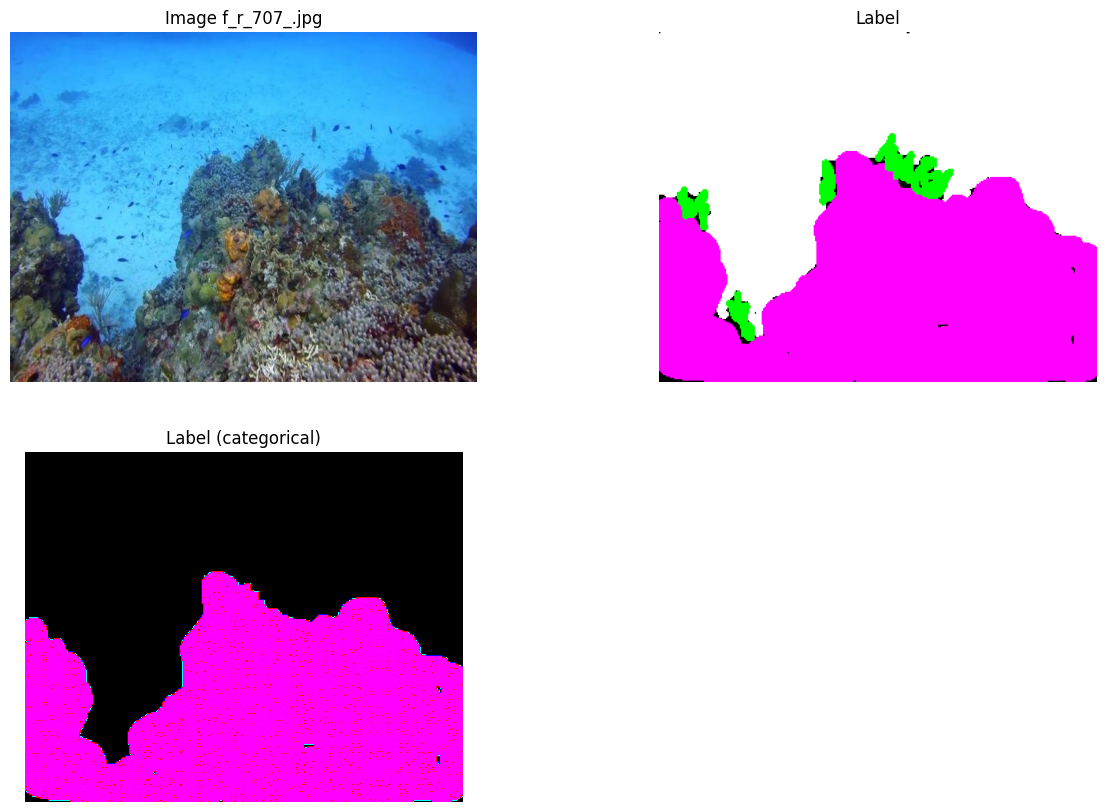

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 4
Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


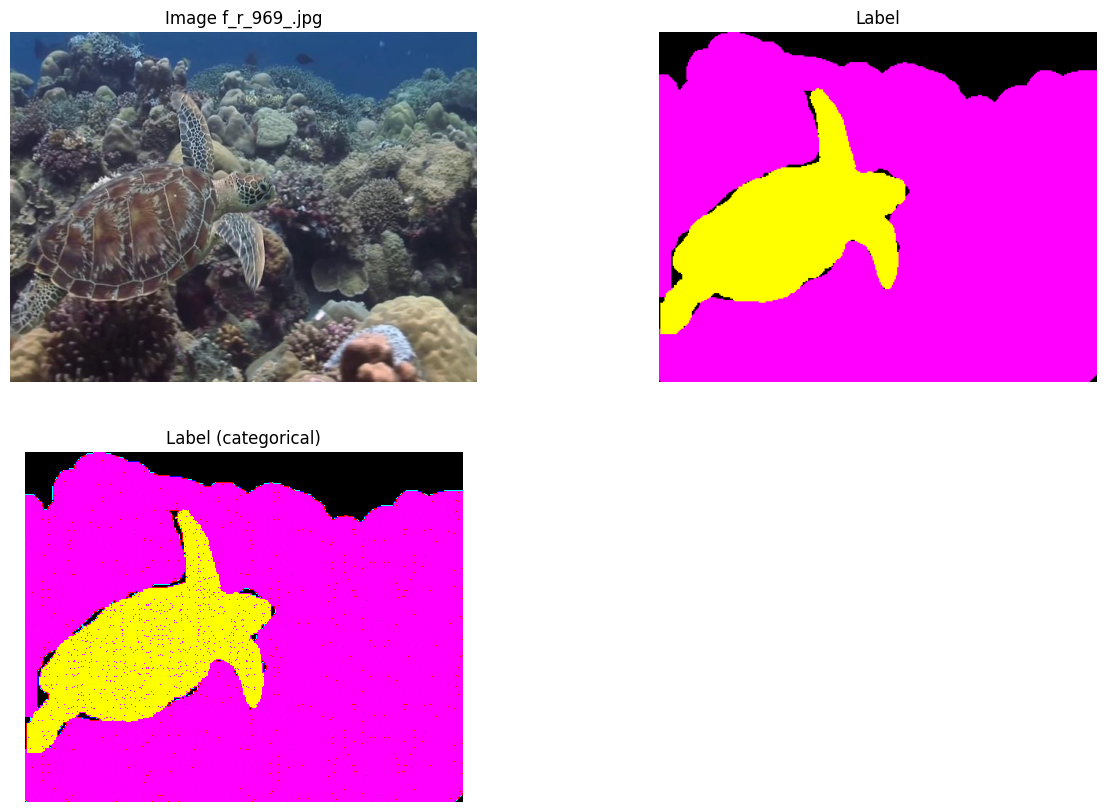

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 5
Image shape: torch.Size([3, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.float32
Label shape: (320, 256), type: <class 'PIL.Image.Image'>


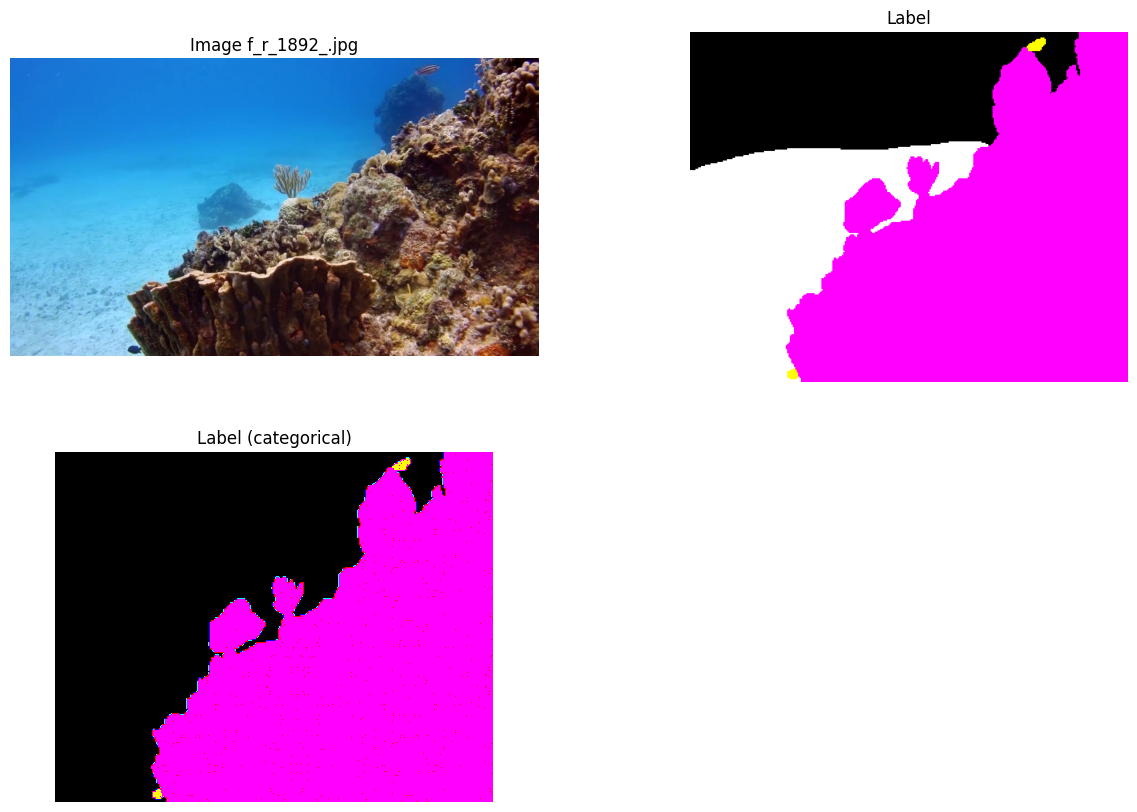

Label masks shape: torch.Size([6, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 1
Labels tensor shape: torch.Size([1, 256, 320]), type: <class 'torch.Tensor'>, dtype: torch.int64, min: 0, max: 5


In [47]:
augmentations = A.Compose([
    # Random rotation
    A.ShiftScaleRotate(
        rotate_limit=0.2 * 360,   # Rotate range ±20% of 360 degrees
        shift_limit=0.05,         # Both width and height shift range
        scale_limit=0.05,         # Zoom range
    ),
    # Random shearing
    A.Affine(
        shear={"x": 0.05, "y": 0.05},  # Apply shear transformations
    ),
    # Horizontal flip
    A.HorizontalFlip(p=0.5)
])

transform_images = transforms.Compose([
    transforms.Resize((256, 320)),
    transforms.ToTensor(), # Converts the image to a tensor with values between 0 and 1
])
transform_labels = transforms.Compose([
    transforms.Resize((256, 320), interpolation = Image.NEAREST),
])

dataset = SuimDataset(
    [(
        os.path.join(dir__dataset_trainvalidation_images, "d_r_103_.jpg"),
        os.path.join(dir__dataset_trainvalidation_labels, "d_r_103_.bmp"),
    )],
    color_mapping = colors_to_5cats,
    transform_images = transform_images,
    transform_labels = transform_labels,
    verbose = True,
)
assert len(dataset) == 1
image, label_masks, labels_tensor = dataset[0]

assert image.shape == (3, 256, 320)
assert image.min() >= 0
assert image.max() <= 1

# image contains 3 classes (0, 1, 2)
assert label_masks.shape == (6, 256, 320)
assert label_masks.min() == 0
assert label_masks.max() == 1
assert label_masks[0].min() == 0
assert label_masks[0].max() == 1
assert label_masks[1].min() == 0
assert label_masks[1].max() == 1
assert label_masks[2].min() == 0
assert label_masks[2].max() == 1
# classes 3, 4, 5 are not present in the label
assert label_masks[3].min() == 0
assert label_masks[3].max() == 0
assert label_masks[4].min() == 0
assert label_masks[4].max() == 0
assert label_masks[5].min() == 0
assert label_masks[5].max() == 0

# image contains 3 classes (0, 1, 2)
assert labels_tensor.shape == (1, 256, 320)
assert labels_tensor.min() == 0
assert labels_tensor.max() == 2

trainvalidation_image_names = [
    "d_r_46_",
    "d_r_715_",
    "d_r_5_",
    "f_r_707_",
    "f_r_969_", 
]

test_image_names = [
    "f_r_1892_",
]

for image_name in trainvalidation_image_names:
    dataset = SuimDataset(
        [(
            os.path.join(dir__dataset_trainvalidation_images, f"{image_name}.jpg"),
            os.path.join(dir__dataset_trainvalidation_labels, f"{image_name}.bmp"),
        )],
        color_mapping = colors_to_5cats,
        transform_images = transform_images,
        transform_labels = transform_labels,
        verbose = True,
    )
    image, label_masks, labels_tensor = dataset[0]

for image_name in test_image_names:
    dataset = SuimDataset(
        [(
            os.path.join(dir__dataset_test_images, f"{image_name}.jpg"),
            os.path.join(dir__dataset_test_labels, f"{image_name}.bmp"),
        )],
        color_mapping = colors_to_5cats,
        transform_images = transform_images,
        transform_labels = transform_labels,
        verbose = True,
    )
    image, label_masks, labels_tensor = dataset[0]


# Models

In [12]:
class Classifier(pl.LightningModule):
    def __init__(self,
                 model,
                 num_classes,
                 lr = 1e-4):
        super().__init__()
        self.model = model
        self.lr = lr
        self.criterion = nn.CrossEntropyLoss()

        self.train_accuracy_f1score = torchmetrics.F1Score(task = "multiclass", num_classes = num_classes)
        self.train_accuracy_mIoU = torchmetrics.JaccardIndex(task = "multiclass", num_classes = num_classes)
        self.train_loss = torchmetrics.MeanMetric()

        self.val_accuracy_f1score = torchmetrics.F1Score(task = "multiclass", num_classes = num_classes)
        self.val_accuracy_mIoU = torchmetrics.JaccardIndex(task = "multiclass", num_classes = num_classes)
        self.val_loss = torchmetrics.MeanMetric()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr = self.lr)

    def training_step(self, batch, batch_idx):
        images, _, labels = batch
        labels = labels.squeeze(1)

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim = 1)

        self.train_accuracy_f1score(preds, labels)
        self.train_accuracy_mIoU(preds, labels)
        self.train_loss(loss)

        self.log("train/acc_f1score_step", self.train_accuracy_f1score, prog_bar = True, on_step = True)
        self.log("train/acc_mIoU_step", self.train_accuracy_mIoU, prog_bar = True, on_step = True)
        self.log("train/loss_step", self.train_loss, prog_bar = True, on_step = True)

        return loss



    def on_train_epoch_end(self):
        self.log("train/acc_f1score_epoch", self.train_accuracy_f1score, on_epoch = True)
        self.log("train/acc_mIoU_epoch", self.train_accuracy_mIoU, on_epoch = True)
        self.log("train/loss_epoch", self.train_loss, on_epoch = True)

    def validation_step(self, batch, batch_idx):
        images, _, labels = batch
        labels = labels.squeeze(1)

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim = 1)

        self.val_accuracy_f1score(preds, labels)
        self.val_accuracy_mIoU(preds, labels)
        self.val_loss(loss)

        self.log("val/acc_f1score_step", self.val_accuracy_f1score, prog_bar = True, on_step = True)
        self.log("val/acc_mIoU_step", self.val_accuracy_mIoU, prog_bar = True, on_step = True)
        self.log("val/loss_step", self.val_loss, prog_bar = True, on_step = True)

        return loss

    def on_validation_epoch_end(self):
        self.log("val/acc_f1score_epoch", self.val_accuracy_f1score, on_epoch = True)
        self.log("val/acc_mIoU_epoch", self.val_accuracy_mIoU, on_epoch = True)
        self.log("val/loss_epoch", self.val_loss, on_epoch = True)
    


    def test_step(self, batch, batch_idx):
        images, _, labels = batch
        labels = labels.squeeze(1)

        outputs = self(images)
        loss = self.criterion(outputs, labels)
        preds = torch.argmax(outputs, dim = 1)

        self.val_accuracy_f1score(preds, labels)
        self.val_accuracy_mIoU(preds, labels)
        self.val_loss(loss)

        self.log("test/acc_f1score_step", self.val_accuracy_f1score, prog_bar = True, on_step = True)
        self.log("test/acc_mIoU_step", self.val_accuracy_mIoU, prog_bar = True, on_step = True)
        self.log("test/loss_step", self.val_loss, prog_bar = True, on_step = True)

        i = 1 # only show the first image in the batch
        fig, ax = plt.subplots(1, 3, figsize = (15, 5))

        _ = ax[0].imshow(images[i].cpu().permute(1, 2, 0))
        _ = ax[0].axis("off")
        _ = ax[0].set_title("Image")

        _ = ax[1].imshow(preds[i].cpu().numpy(), cmap = cmap, norm = norm)
        _ = ax[1].axis("off")
        _ = ax[1].set_title("Prediction")

        _ = ax[2].imshow(labels[i].cpu().squeeze(0), cmap = cmap, norm = norm)
        _ = ax[2].axis("off")
        _ = ax[2].set_title("Label")

        plt.show()

        return loss


    def on_test_epoch_end(self):
        self.log("test/acc_f1score", self.val_accuracy_f1score, on_epoch = True)
        self.log("test/acc_mIoU", self.val_accuracy_mIoU, on_epoch = True)
        self.log("test/loss", self.val_loss, on_epoch = True)

## SuimNET VVG

In [13]:
class UpSampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UpSampleBlock, self).__init__()
        self.upsample = nn.Upsample(scale_factor = 2, mode = 'bilinear', align_corners = False)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size = 3, padding = 1, stride = 1)
        self.relu = nn.ReLU(inplace = True)
        self.bn = nn.BatchNorm2d(out_channels, momentum = 0.8)

    def forward(self, x, skip):
        x = self.upsample(x)
        x = self.conv(x)
        x = self.relu(x)
        x = self.bn(x)
        x = torch.cat([x, skip], dim = 1)
        return x


class SUIMNetVGG16(nn.Module):
    def __init__(self, num_classes = 8):
        super(SUIMNetVGG16, self).__init__()
        vgg = models.vgg16(weights = VGG16_Weights.IMAGENET1K_V1)
        self.encoder1 = nn.Sequential(*vgg.features[:5])     # Block 1
        self.encoder2 = nn.Sequential(*vgg.features[5:10])   # Block 2
        self.encoder3 = nn.Sequential(*vgg.features[10:17])  # Block 3
        self.encoder4 = nn.Sequential(*vgg.features[17:24])  # Block 4

        self.decoder1 = UpSampleBlock(512,       768)
        self.decoder2 = UpSampleBlock(768 + 256, 384)
        self.decoder3 = UpSampleBlock(384 + 128, 192)
        self.final_deconv = nn.ConvTranspose2d(256, 192, kernel_size = 2, stride = 2)
        self.output = nn.Conv2d(192, num_classes, kernel_size = 3, padding = 1)

    def forward(self, x):
        # Encoder
        e1 = self.encoder1(x)
        e2 = self.encoder2(e1)
        e3 = self.encoder3(e2)
        e4 = self.encoder4(e3)

        # Decoder
        d1 = self.decoder1(e4, e3)
        d2 = self.decoder2(d1, e2)
        d3 = self.decoder3(d2, e1)
        d4 = self.final_deconv(d3)
        out = self.output(d4)
        return torch.sigmoid(out)

### Tests

In [14]:
model = SUIMNetVGG16(num_classes = 8)
input_tensor = torch.randn(1, 3, 320, 256)  # Batch size 1, RGB, 320x256
output = model(input_tensor)
assert output.shape == (1, 8, 320, 256)

model = SUIMNetVGG16(num_classes=6)
input_tensor = torch.randn(8, 3, 320, 256)  # Batch size 8, RGB, 320x256
output = model(input_tensor)
assert output.shape == (8, 6, 320, 256)

### Run

In [15]:
augmentations = A.Compose([
    # Random rotation
    A.ShiftScaleRotate(
        rotate_limit=0.2 * 360,   # Rotate range ±20% of 360 degrees
        shift_limit=0.05,         # Both width and height shift range
        scale_limit=0.05,         # Zoom range
    ),
    # Random shearing
    A.Affine(
        shear={"x": 0.05, "y": 0.05},  # Apply shear transformations
    ),
    # Horizontal flip
    A.HorizontalFlip(p=0.5)
], is_check_shapes=False)

transform_images = transforms.Compose([
    transforms.Resize((256, 320)),
    transforms.ToTensor(), # Converts the image to a tensor with values between 0 and 1
])
transform_labels = transforms.Compose([
    transforms.Resize((256, 320)),
])

batch_size = 8
num_workers = 2

trainvalidation_dataset = SuimDataset(trainvalidation_tuples_paths, colors_to_5cats, transform_images, transform_labels, augmentations=augmentations)
trainvalidation_dataloader = DataLoader(trainvalidation_dataset, batch_size = batch_size, shuffle = True) #, num_workers = num_workers) #, persistent_workers = True, pin_memory = True)

test_dataset = SuimDataset(test_tuples_paths, colors_to_5cats, transform_images, transform_labels, augmentations=augmentations)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False) #, num_workers = num_workers) #, persistent_workers = True, pin_memory = True)


model = SUIMNetVGG16(num_classes = 6)
classifier = Classifier(model = model, num_classes = 6, lr = 1e-4)

checkpoint_callback = ModelCheckpoint(
    mode = "min",
    save_weights_only = True,
    save_top_k = 1,
    filename = "SUIMNetVGG16_{epoch:02d}",
    verbose = True
)

trainer = pl.Trainer(
    max_epochs = 50,
    callbacks = [checkpoint_callback],
    accelerator = "gpu",
    devices = 1 if torch.cuda.is_available() else None,
    log_every_n_steps = 10
)

trainer_result_fit = trainer.fit(classifier, trainvalidation_dataloader, test_dataloader)
trainer_result_test = trainer.test(classifier, test_dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                   | Type                   | Params | Mode 
--------------------------------------------------------------------------
0 | model                  | SUIMNetVGG16           | 15.8 M | train
1 | criterion              | CrossEntropyLoss       | 0      | train
2 | train_accuracy_f1score | MulticlassF1Score      | 0      | train
3 | train_accuracy_mIoU    | MulticlassJaccardIndex | 0      | train
4 | train_loss             | MeanMetric             | 0      | train
5 | val_accuracy_f1score   | MulticlassF1Score      | 0      | train
6 | val_accuracy_mIoU      | MulticlassJaccardIndex | 0      | tra

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Python312\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Python312\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

## SuimNET RSB

In [ ]:
class RSBBlock(nn.Module):
    '''
    Residual block with skip connection

    Args:
        input_channels (int): Number of input channels
        output_channels (list): List of 4 integers representing the number of output channels for each sub-block
        stride (int): Stride for the first convolution
        skip (bool): If True, the block will have a skip connection
    '''

    def __init__(self, input_channels, output_channels, stride=1, skip=True):
        '''
        Initializes the block
        
        Args:
            input_channels (int): Number of input channels
            output_channels (list): List of 4 integers representing the number of output channels for each sub-block
            stride (int): Stride for the first convolution
            skip (bool): If True, the block will have a skip connection
        '''
        super(RSBBlock, self).__init__()
        self.skip = skip
        out1, out2, out3, out4 = output_channels

        # sub-block 1
        self.conv1 = nn.Conv2d(in_channels=input_channels, out_channels=out1, kernel_size=1, stride=stride, padding=0)
        self.bn1 = nn.BatchNorm2d(out1, momentum=0.8)

        # sub-block 2
        self.conv2 = nn.Conv2d(in_channels=out1, out_channels=out2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out2, momentum=0.8)

        # sub-block 3
        self.conv3 = nn.Conv2d(in_channels=out2, out_channels=out3, kernel_size=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out3, momentum=0.8)

        if not skip:
            self.conv_shortcut = nn.Conv2d(in_channels=input_channels, out_channels=out4, kernel_size=1, stride=stride, padding=0)
            self.bn_shortcut = nn.BatchNorm2d(out4, momentum=0.8)


    def forward(self, x):
        '''
        Forward pass through the block
        
        Args:
            x (torch.Tensor): Input tensor
        '''
        # Sub-block 1
        out = F.relu(self.bn1(self.conv1(x)))

        # Sub-block 2
        out = F.relu(self.bn2(self.conv2(out)))

        # Sub-block 3
        out = self.bn3(self.conv3(out))

        # Shortcut connection
        if self.skip:
            shortcut = x
        else:
            shortcut = self.bn_shortcut(self.conv_shortcut(x))

        # Add and activate
        out += shortcut
        out = F.relu(out)
        return out


class ConcatSkipBlock(nn.Module):
    '''
    Concatenation block with skip connection
    
    Args:
        in_channels (int): Number of input channels
        out_channels (int): Number of output channels
        kernel_size (int): Kernel size for the convolution
    '''

    def __init__(self, in_channels, out_channels, kernel_size=3):
        '''
        Initializes the block
        
        Args:
            in_channels (int): Number of input channels
            out_channels (int): Number of output channels
            kernel_size (int): Kernel size for the convolution
        '''
        super(ConcatSkipBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=kernel_size, stride=1, padding=1)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.8)

    def forward(self, layer_input, skip_input):
        '''
        Forward pass through the block
        
        Args:
            layer_input (torch.Tensor): Input tensor
            skip_input (torch.Tensor): Skip connection tensor
        '''
        u = self.conv(layer_input)
        u = self.bn(u)
        u = F.relu(u)
        u = torch.cat((u, skip_input), dim=1)
        return u


class SUIMEncoderRSB(nn.Module):
    '''
    Encoder for the SUIMNet with Residual Skip Blocks (RSB)
    
    Args:
        channels (int): Number of input channels
    '''

    def __init__(self, channels=3):
        '''
        Initializes the encoder
        
        Args:
            channels (int): Number of input channels
        '''
        super(SUIMEncoderRSB, self).__init__()

        # encoding block 1
        self.conv1 = nn.Conv2d(channels, 64, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.8)

        # encoding block 2
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.rsb2_1 = RSBBlock(input_channels=64, output_channels=[64, 64, 128, 128], stride=2, skip=False)
        self.rsb2_2 = RSBBlock(input_channels=128, output_channels=[64, 64, 128, 128], stride=1, skip=True)
        self.rsb2_3 = RSBBlock(input_channels=128, output_channels=[64, 64, 128, 128], stride=1, skip=True)

        # encoding block 3
        self.rsb3_1 = RSBBlock(input_channels=128, output_channels=[128, 128, 256, 256], stride=2, skip=False)
        self.rsb3_2 = RSBBlock(input_channels=256, output_channels=[128, 128, 256, 256], stride=1, skip=True)
        self.rsb3_3 = RSBBlock(input_channels=256, output_channels=[128, 128, 256, 256], stride=1, skip=True)
        self.rsb3_4 = RSBBlock(input_channels=256, output_channels=[128, 128, 256, 256], stride=1, skip=True)

    def forward(self, x):
        ''' Forward pass through the encoder
        Args:
            x (torch.Tensor): Input tensor
        '''
        # encoding block 1
        enc_1 = self.conv1(x)

        # encoding block 2
        x = F.relu(self.bn1(enc_1))
        x = self.pool1(x)
        x = self.rsb2_1(x)
        x = self.rsb2_2(x)
        x = self.rsb2_3(x)
        enc_2 = x

        # encoding block 3
        x = self.rsb3_1(x)
        x = self.rsb3_2(x)
        x = self.rsb3_3(x)
        x = self.rsb3_4(x)
        enc_3 = x

        return [enc_1, enc_2, enc_3]

class SUIMDecoderRSB(nn.Module):
    '''
    Decoder for the SUIMNet with Residual Skip Blocks (RSB)
    
    Args:
        num_classes (int): Number of classes
    '''

    def __init__(self, num_classes=8):
        '''
        Initializes the decoder
        
        Args:
            num_classes (int): Number of classes
        '''
        super(SUIMDecoderRSB, self).__init__()

        # decoding block 1
        self.conv_dec_1 = nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1)
        self.bn_dec_1 = nn.BatchNorm2d(num_features=256)
        self.concat_skip_1 = ConcatSkipBlock(in_channels=128, out_channels=256)

        # decoding block 2a
        self.conv_dec_2 = nn.Conv2d(in_channels=512, out_channels=256, kernel_size=3, padding=1)
        self.bn_dec_2 = nn.BatchNorm2d(num_features=256)
        
        # decoding block 2b
        self.conv_dec_2s = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn_dec_2s = nn.BatchNorm2d(num_features=128)
        self.concat_skip_2 = ConcatSkipBlock(in_channels=64, out_channels=128)

        # decoding block 3
        self.conv_dec_3 = nn.Conv2d(in_channels=256, out_channels=128, kernel_size=3, padding=1)
        self.bn_dec_3 = nn.BatchNorm2d(num_features=128)
        self.conv_dec_3s = nn.Conv2d(in_channels=128, out_channels=64, kernel_size=3, padding=1)
        self.bn_dec_3s = nn.BatchNorm2d(num_features=64)

        # output layer
        self.output_conv = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=3, padding=1)

    def forward(self, enc_1, enc_2, enc_3):
        ''' Forward pass through the decoder 
        
        Args:
            enc_1 (torch.Tensor): Output of the first encoder block
            enc_2 (torch.Tensor): Output of the second encoder block
            enc_3 (torch.Tensor): Output of the third encoder block
        '''
        # decoding block 1
        dec_1 = self.conv_dec_1(enc_3)
        dec_1 = self.bn_dec_1(dec_1)
        dec_1 = F.interpolate(dec_1, scale_factor=2, mode='bilinear', align_corners=False)

        # padding adjustments
        dec_1s = self.concat_skip_1(enc_2, dec_1)

        # decoding block 2a
        dec_2a = self.conv_dec_2(dec_1s)
        dec_2a = self.bn_dec_2(dec_2a)
        dec_2a = F.interpolate(dec_2a, scale_factor=2, mode='bilinear', align_corners=False)

        # decoding block 2b
        dec_2b = self.conv_dec_2s(dec_2a)
        dec_2b = self.bn_dec_2s(dec_2b)
        dec_2b = F.interpolate(dec_2b, scale_factor=2, mode='bilinear', align_corners=False)

        # padding adjustments
        dec_2b = self.concat_skip_2(enc_1, dec_2b)

        # decoding block 3
        dec_3 = self.conv_dec_3(dec_2b)
        dec_3 = self.bn_dec_3(dec_3)
        dec_3s = self.conv_dec_3s(dec_3)
        dec_3s = self.bn_dec_3s(dec_3s)

        # output layer
        out = self.output_conv(dec_3s)
        out = torch.sigmoid(out)
        return out


class SUIMNetRSB(nn.Module):
    '''
    SUIMNet with Residual Skip Blocks (RSB)
    
    Args:
        num_classes (int): Number of classes
    '''
    
    def __init__(self, num_classes=8):
        '''
        Initializes the model

        Args:
            num_classes (int): Number of classes
        '''
        super(SUIMNetRSB, self).__init__()
        self.encoder = SUIMEncoderRSB()
        self.decoder = SUIMDecoderRSB(num_classes)

    def forward(self, x):
        '''
        Forward pass through the network
        
        Args:
            x (torch.Tensor): Input tensor
        '''
        enc_1, enc_2, enc_3 = self.encoder(x)
        out = self.decoder(enc_1, enc_2, enc_3)
        return out

### Tests

In [ ]:
model = SUIMNetRSB(num_classes=8)
input_tensor = torch.randn(1, 3, 320, 256)  # Batch size 1, RGB, 320x256
output = model(input_tensor)
assert output.shape == (1, 8, 320, 256)

model = SUIMNetRSB(num_classes=6)
input_tensor = torch.randn(8, 3, 320, 256)  # Batch size 8, RGB, 320x256
output = model(input_tensor)
assert output.shape == (8, 6, 320, 256)

### Run

In [ ]:
augmentations = A.Compose([
    # Random rotation
    A.ShiftScaleRotate(
        rotate_limit=0.2 * 360,   # Rotate range ±20% of 360 degrees
        shift_limit=0.05,         # Both width and height shift range
        scale_limit=0.05,         # Zoom range
    ),
    # Random shearing
    A.Affine(
        shear={"x": 0.05, "y": 0.05},  # Apply shear transformations
    ),
    # Horizontal flip
    A.HorizontalFlip(p=0.5)
], is_check_shapes=False)

transform_images = transforms.Compose([
    transforms.Resize((256, 320)),
    transforms.ToTensor(), # Converts the image to a tensor with values between 0 and 1
])
transform_labels = transforms.Compose([
    transforms.Resize((256, 320)),
])

batch_size = 8
num_workers = 2

trainvalidation_dataset = SuimDataset(trainvalidation_tuples_paths, colors_to_5cats, transform_images, transform_labels, augmentations=augmentations)
trainvalidation_dataloader = DataLoader(trainvalidation_dataset, batch_size = batch_size, shuffle = True) #, num_workers = num_workers) #, persistent_workers = True, pin_memory = True)

test_dataset = SuimDataset(test_tuples_paths, colors_to_5cats, transform_images, transform_labels, augmentations=augmentations)
test_dataloader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False) #, num_workers = num_workers) #, persistent_workers = True, pin_memory = True)


model = SUIMNetRSB(num_classes = 6)
classifier = Classifier(model = model, num_classes = 6, lr = 1e-4)

checkpoint_callback = ModelCheckpoint(
    mode = "min",
    save_weights_only = True,
    save_top_k = 1,
    filename = "SUIMNetRSB_{epoch:02d}",
    verbose = True
)

trainer = pl.Trainer(
    max_epochs = 50,
    callbacks = [checkpoint_callback],
    accelerator = "gpu",
    devices = 1 if torch.cuda.is_available() else None,
    log_every_n_steps = 10
)

trainer.fit(classifier, trainvalidation_dataloader, test_dataloader)
trainer_result_test = trainer.test(classifier, test_dataloader)